In [ ]:
from keras.datasets import imdb
(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=200)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


IMDB 데이터셋을 가져옴
db.load_data()는 IMDB 영화 리뷰 데이터를 불러오는 함수
num_words=200 은 가장 자주 등장하는 200개의 단어만 사용하겠다는 의미

In [ ]:
print(train_input.shape, test_input.shape)

(25000,) (25000,)


학습용 리뷰가 25,000개, 테스트용 리뷰도 25,000개 있다는 뜻

In [ ]:
print(len(train_input[0]))

218


첫 번째 리뷰의 단어 수 출력

In [ ]:
print(len(train_input[1]))

189


두번째 리뷰 단어수 출력

In [ ]:
print(train_input[0])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 2, 2, 66, 2, 4, 173, 36, 2, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 2, 2, 5, 150, 4, 172, 112, 167, 2, 2, 2, 39, 4, 172, 2, 2, 17, 2, 38, 13, 2, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 2, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 2, 12, 8, 2, 8, 106, 5, 4, 2, 2, 16, 2, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 2, 28, 77, 52, 5, 14, 2, 16, 82, 2, 8, 4, 107, 117, 2, 15, 2, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 2, 26, 2, 2, 46, 7, 4, 2, 2, 13, 104, 88, 4, 2, 15, 2, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 2, 22, 21, 134, 2, 26, 2, 5, 144, 30, 2, 18, 51, 36, 28, 2, 92, 25, 104, 4, 2, 65, 16, 38, 2, 88, 12, 16, 2, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


숫자 배열 자체가 첫 번째 리뷰의 텍스트를 숫자로 표현한 것

In [ ]:
print(train_target[:20])

[1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1]


train_target[:20]은 학습용 리뷰의 첫 20개의 정답 레이블
0은 부정을, 1은 긍정을 의미

In [ ]:
from sklearn.model_selection import train_test_split
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)


학습용 리뷰 데이터를 80% 학습용, 20% 검증용으로 나누어 모델 학습 시 성능을 검증할 수 있도록 준비하는 과정

In [ ]:
import numpy as np
lengths = np.array([len(x) for x in train_input])

각 리뷰의 길이를 계산한 리스트를 만드는 것

In [ ]:
print(np.mean(lengths), np.median(lengths))

239.00925 178.0


리뷰 길이의 평균과 중앙값

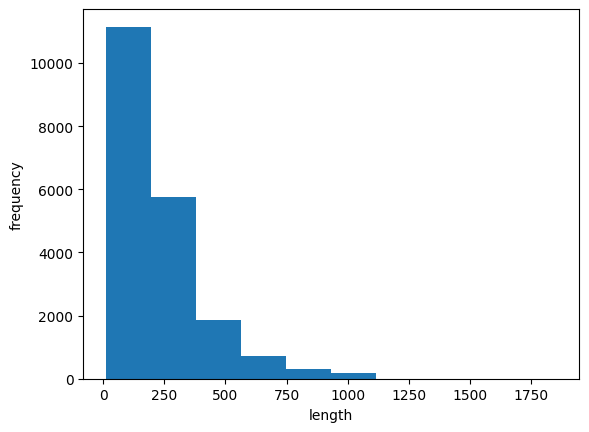

In [ ]:
import matplotlib.pyplot as plt
plt.hist(lengths)
plt.xlabel('length')
plt.ylabel('frequency')
plt.show()

학습용 리뷰 길이의 분포를 히스토그램으로 시각화
x축은 리뷰 길이, y축은 해당 길이를 가진 리뷰 수
작성한 히스토그램을 화면에 표시

In [ ]:
from keras.preprocessing.sequence import pad_sequences
train_seq = pad_sequences(train_input, maxlen=100)

pad_sequences는 리뷰 길이를 지정한 길이로 맞추는 함수

모든 리뷰가 길이 100인 2차원 배열로 변환
이제 신경망 모델의 입력으로 바로 사용 가능

In [ ]:
print(train_seq.shape)

(20000, 100)


패딩을 거친 후, 학습용 리뷰 데이터는 2차원 배열로 변환됨. 첫 번째 차원은 리뷰 개수, 두 번째 차원은 각 리뷰의 길이

In [ ]:
print(train_seq[0])

[ 10   4  20   9   2   2   2   5  45   6   2   2  33   2   8   2 142   2
   5   2  17  73  17   2   5   2  19  55   2   2  92  66 104  14  20  93
  76   2 151  33   4  58  12 188   2 151  12   2  69   2 142  73   2   6
   2   7   2   2 188   2 103  14  31  10  10   2   7   2   5   2  80  91
   2  30   2  34  14  20 151  50  26 131  49   2  84  46  50  37  80  79
   6   2  46   7  14  20  10  10   2 158]


패딩 후 첫 번째 리뷰의 데이터를 확인

숫자	의미:
0	패딩(padding) → 실제 단어가 없는 자리
1, 14, 22 ...	실제 단어 인덱스 → 각 단어를 고유 숫자로 변환한 것

In [ ]:
print(train_input[0][-10:])

[6, 2, 46, 7, 14, 20, 10, 10, 2, 158]


첫 번째 리뷰의 마지막 10단어 인덱스를 확인

In [ ]:
print(train_seq[5])

[  0   0   0   0   1   2 195  19  49   2   2 190   4   2   2   2 183  10
  10  13  82  79   4   2  36  71   2   8   2  25  19  49   7   4   2   2
   2   2   2  10  10  48  25  40   2  11   2   2  40   2   2   5   4   2
   2  95  14   2  56 129   2  10  10  21   2  94   2   2   2   2  11 190
  24   2   2   7  94   2   2  10  10  87   2  34  49   2   7   2   2   2
   2   2   2   2  46  48  64  18   4   2]


패딩 후 여섯 번째 리뷰의 숫자 시퀀스를 확인

In [ ]:
val_seq = pad_sequences(val_input, maxlen=100)

pad_sequences로 학습용과 검증용 모든 리뷰를 길이 100으로 맞춰 0 패딩 처리하여 LSTM 모델 입력 준비를 완료

In [ ]:
import keras
model = keras.Sequential()
model.add(keras.layers.Input(shape=(100,200)))
model.add(keras.layers.SimpleRNN(8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

keras.Sequential() → 레이어를 순차적으로 쌓는 신경망 모델 생성

100단어 시퀀스를 입력으로 받아 RNN 8개 뉴런으로 순차 정보를 학습하고, Dense 출력층에서 0~1 확률로 긍정/부정을 예측하는 구조

In [ ]:
train_oh = keras.utils.to_categorical(train_seq)

숫자로 된 리뷰 시퀀스를 원-핫 벡터로 바꿔, RNN이 바로 학습할 수 있는 3차원 입력 형태로 만듬

In [ ]:
print(train_oh.shape)

(20000, 100, 200)


원-핫 벡터로 변환한 학습용 리뷰 데이터의 형태를 확인시, (리뷰 개수, 시퀀스 길이, 단어 수) 3차원 배열로 나타남

In [ ]:
print(train_oh[0][0][:12])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


train_oh → 원-핫 인코딩된 학습 데이터 배열

[0] → 첫 번째 샘플

[0] → 첫 번째 샘플의 첫 번째 요소 (이미지라면 첫 번째 행 혹은 첫 번째 특성 벡터)

[:12] → 그 행(혹은 벡터)의 처음 12개 값

In [ ]:
print(np.sum(train_oh[0][0]))

1.0


첫 번째 샘플(0번째)의 첫 번째 벡터(0번째)에 있는 모든 값을 더한 것
원-핫 인코딩된 벡터라면:

대부분 값이 0이고, 딱 하나만 1이므로

합을 계산하면 항상 1이 나옴

In [ ]:
val_oh = keras.utils.to_categorical(val_seq)

검증 데이터(val_seq)를 모델이 학습할 수 있는 원-핫 형태로 변환하는 역할

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         1,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,681 (6.57 KB)

 Trainable params: 1,681 (6.57 KB)

 Non-trainable params: 0 (0.00 B)

케라스(Keras) 모델의 구조와 파라미터 수를 한눈에 보여주는 요약 정보를 출력하는 명령

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-simplernn-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model.fit(train_oh, train_target, epochs=100, batch_size=64,
                    validation_data=(val_oh, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.5130 - loss: 0.6931 - val_accuracy: 0.6578 - val_loss: 0.6366
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6570 - loss: 0.6270 - val_accuracy: 0.7034 - val_loss: 0.5853
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.7002 - loss: 0.5814 - val_accuracy: 0.7208 - val_loss: 0.5598
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7205 - loss: 0.5540 - val_accuracy: 0.7238 - val_loss: 0.5565
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.7268 - loss: 0.5508 - val_accuracy: 0.7292 - val_loss: 0.5543
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.7281 - loss: 0.5413 - val_accuracy: 0.7180 - val_loss: 0.5643
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.7298 - loss: 0.5429 - val_accuracy: 0.7252 - val_loss: 0.5529
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7380 - loss: 0.5334 

optimizer='adam' → Adam 옵티마이저를 사용해 가중치를 업데이트

loss='binary_crossentropy' → 이진 분류 손실 함수를 사용

metrics=['accuracy'] → 학습 중 정확도(accuracy)를 모니터링

학습 중 검증 손실이 가장 낮은 모델만 저장

파일 이름: 'best-simplernn-model.keras'

조기 종료(Early stopping): 검증 손실이 개선되지 않으면 학습을 멈춤

patience=3 → 3 epoch 동안 개선 없으면 중단

restore_best_weights=True → 중단 시 최고 성능 모델의 가중치로 되돌림

train_oh, train_target → 학습 데이터와 레이블

epochs=100 → 최대 100번 반복 학습

batch_size=64 → 64개 샘플씩 미니배치 학습

validation_data=(val_oh, val_target) → 검증 데이터로 성능 모니터링

callbacks=[checkpoint_cb, early_stopping_cb] → 체크포인트와 조기 종료 적용

반환값 history → 학습 과정 손실(loss)과 정확도(accuracy) 기록

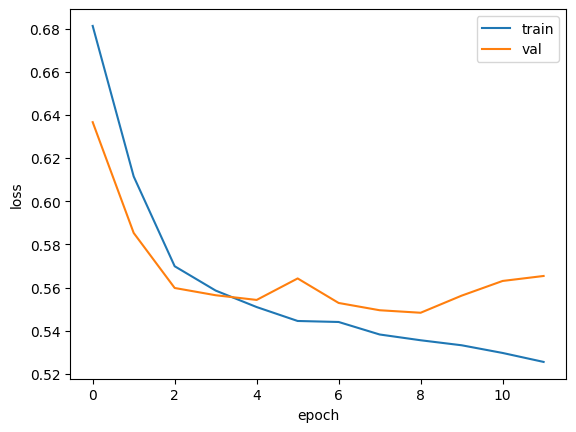

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

history.history에는 epoch별 학습 손실, 학습 정확도, 검증 손실, 검증 정확도가 딕셔너리 형태로 저장

학습 손실과 검증 손실을 epoch별로 선 그래프로 그림
label은 범례(legend) 이름

x축: epoch (학습 반복 횟수)
y축: 손실 값
범례 표시
그래프 출력

In [ ]:
print(train_seq.nbytes, train_oh.nbytes)

8000000 3200000000


train_seq.nbytes → train_seq 배열이 메모리에서 차지하는 바이트 수

train_oh.nbytes → train_oh 배열이 메모리에서 차지하는 바이트 수

In [ ]:
(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words=500)
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)
train_seq= pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

imdb.load_data(num_words=500) → IMDB 영화 리뷰 데이터를 부

num_words=500 → 가장 자주 등장하는 500개의 단어만 사용 (나머지는 무시)

반환값:

train_input → 학습 리뷰 데이터 (정수 인덱스로 변환됨)

train_target → 학습 레이블 (긍정=1, 부정=0)

test_input, test_target → 테스트 데이터

학습 데이터 중 20%를 검증 데이터(val_input, val_target)로 분리

random_state=42 → 실행할 때마다 동일하게 분리되도록 고정

결과:

train_input, train_target → 실제 학습용

val_input, val_target → 모델 성능 평가용

리뷰마다 길이가 다르므로 길이를 100으로 맞춤

길이가 짧으면 0으로 패딩(pad), 길면 자름(truncate)

결과:

train_seq.shape → (샘플 수, 100)

val_seq.shape → (검증 샘플 수, 100)

In [ ]:
model_emb = keras.Sequential()
model_emb.add(keras.layers.Input(shape=(100,)))
model_emb.add(keras.layers.Embedding(500,16))
model_emb.add(keras.layers.SimpleRNN(8))
model_emb.add(keras.layers.Dense(1, activation='sigmoid'))

층(layer)을 순서대로 쌓는 케라스 모델 생성

입력 데이터의 형태를 지정

각 리뷰는 길이 100인 시퀀스 (앞서 pad_sequences로 맞춘 길이)

정수 인덱스 형태 (단어 ID)

단어 ID → 16차원 벡터로 변환

500 → 단어 사전 크기 (최빈 500단어)

16 → 각 단어를 표현할 벡터 차원

결과: (batch_size, 100, 16) 형태의 3D 텐서
순환 신경망(RNN)으로 시퀀스 정보 처리

8 → 출력 차원 (RNN의 hidden state 크기)

입력: (batch_size, 100, 16)

출력: (batch_size, 8) (마지막 시점의 hidden state만 반환)

1개의 노드로 출력 → 긍정/부정 분류 (0/1)

sigmoid → 출력값을 0~1 사이 확률로 변환

In [ ]:
model_emb.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,209 (32.07 KB)

 Trainable params: 8,209 (32.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_emb.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
checkpoint_cb= keras.callbacks.ModelCheckpoint('best-embedding-model.keras',
                                               save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model_emb.fit(train_seq, train_target, epochs=100, batch_size=64,
                        validation_data=(val_seq, val_target),
                        callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.6083 - loss: 0.6504 - val_accuracy: 0.6748 - val_loss: 0.6039
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7504 - loss: 0.5258 - val_accuracy: 0.7698 - val_loss: 0.4881
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7869 - loss: 0.4703 - val_accuracy: 0.7762 - val_loss: 0.4738
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7982 - loss: 0.4503 - val_accuracy: 0.7740 - val_loss: 0.4850
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7979 - loss: 0.4377 - val_accuracy: 0.7756 - val_loss: 0.4738
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7975 - loss: 0.4389 - val_accuracy: 0.7780 - val_loss: 0.4665
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8118 - loss: 0.4226 - val_accuracy: 0.7776 - val_loss: 0.4655
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8137 - loss: 0.4131 -

모델 구조: Embedding → SimpleRNN → Dense(1, sigmoid)

학습: Adam 최적화 + 이진 크로스엔트로피 손실

학습 과정:

검증 손실이 가장 낮은 모델 저장

개선 없으면 학습 조기 종료

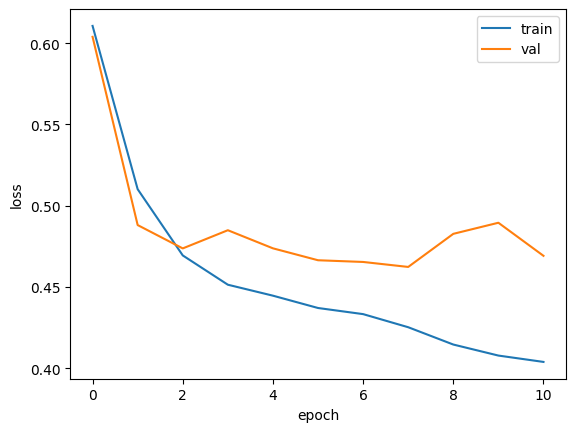

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

목적: 학습 과정에서 손실(loss) 변화를 시각화

history.history['loss'] → 학습 데이터 손실

history.history['val_loss'] → 검증 데이터 손실

plt.legend() → 그래프에 어떤 선이 train/val인지 표시

그래프 해석:

손실이 점점 줄어들면 학습이 잘 되고 있음

검증 손실이 학습 손실보다 훨씬 크거나 늘어나면 오버피팅